# Example Notebook

In [1]:
from pynwb import NWBHDF5IO
import numpy as np
import datajoint as dj
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from bisect import bisect_left

dj_local_conf_path = "/Users/pauladkisson/Documents/CatalystNeuro/Spyglass/spyglass/dj_local_conf.json"
dj.config.load(dj_local_conf_path)  # load config for database connection info

# General Spyglass Imports
import spyglass.common as sgc  # this import connects to the database
import spyglass.data_import as sgi
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
import spyglass.lfp as sglfp

# Spike Sorting Imports
from spyglass.spikesorting.spikesorting_merge import SpikeSortingOutput
import spyglass.spikesorting.v1 as sgs
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
from spyglass.spikesorting.analysis.v1.group import UnitSelectionParams
from spyglass.spikesorting.analysis.v1.unit_annotation import UnitAnnotation
from tqdm import tqdm

/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-01-15 11:11:31,105][INFO]: DataJoint is configured from /Users/pauladkisson/Documents/CatalystNeuro/Spyglass/spyglass/dj_local_conf.json
[2026-01-15 11:11:31,162][INFO]: DataJoint 0.14.6 connected to root@localhost:3306
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
sgc.Session()

nwb_file_name name of the NWB file,subject_id,institution_name,lab_name,session_id,session_description,session_start_time,timestamps_reference_time,experiment_description
H3022-210805_.nwb,H3022,University of Edinburgh,Wood/Dudchenko lab,210805,"Exploration, sleep and cue rotation",2021-08-05 17:06:23,2021-08-05 17:06:23,Basic properties of the head-direction system


## Single-session Analysis

We will start by looking at a single example session

In [3]:
nwb_file_name = get_nwb_copy_filename("H3022-210805.nwb")
sgc.Session() & {"nwb_file_name": nwb_file_name}

nwb_file_name name of the NWB file,subject_id,institution_name,lab_name,session_id,session_description,session_start_time,timestamps_reference_time,experiment_description
H3022-210805_.nwb,H3022,University of Edinburgh,Wood/Dudchenko lab,210805,"Exploration, sleep and cue rotation",2021-08-05 17:06:23,2021-08-05 17:06:23,Basic properties of the head-direction system


By looking at the subject table, we can see that our subject is 22 days old with the wild-type genotype. 

In [4]:
sgc.Subject() & {"subject_id": "H3022"}

subject_id,age,description,genotype,sex,species
H3022,P22D,"All experimental procedures were carried out under a UK Home Office project licence, approved by the Animal Welfare and Ethical Review Board (AWERB) of the University of Edinburgh College of Medicine and Veterinary Medicine, and conformed with the UK Animals (Scientific Procedures) Act 1986. Long-Evans male Fmr1-/y and WT rat littermates were bred in-house by crossing WT sires with Fmr1-heterozygous dams. The original null mutants were generated using zinc finger nucleases targeting Fmr1 exon 1 with a construct containing the sequence coding for eGFP. The Fmr1-/y males from the resulting line do not express either FMRP or eGFP, as described in 4. The rats used for the experiments described in this thesis were bred in-house and were housed with their parents and siblings up until weaning at postnatal day 21 (P21). After weaning, animals were housed with their littermates. They were kept on a 12h/12h light/dark cycle (lights on at 7am) and fed ad libitum on standard laboratory chow, with supplementation of water-soaked breeding chow after the surgery. 24 hours after the end of the surgery, adult rats were placed on mild food restriction to encourage foraging, with their body weight not falling below 90% of their free feeding weight. Pairs of rats (i.e. 1 WT and 1 Fmr1-/y rat) were randomly allocated to the experiment from the litter. Experimenters were blind to the genotype of the animals chosen throughout experiments including surgery, recordings, and pre-processing, and were unblinded to conduct statistical comparisons between groups.",WT,M,Rattus norvegicus


By looking at the TaskEpoch table, we can see the 4 sleep-wake epochs. 

In [5]:
sgc.TaskEpoch & {"nwb_file_name": nwb_file_name}

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),task_name,camera_name,interval_list_name descriptive name of this interval list,task_environment the environment the animal was in,camera_names list of keys corresponding to entry in CameraDevice
H3022-210805_.nwb,1,wake,None,01,cylindrical_open_field,=BLOB=
H3022-210805_.nwb,2,sleep,None,02,sleep_container,=BLOB=
H3022-210805_.nwb,3,wake,None,03,cylindrical_open_field,=BLOB=
H3022-210805_.nwb,4,wake_cue_rot,None,04,cylindrical_open_field,=BLOB=


This table references interval lists which contain the actual start time and stop time of each of these epochs.
Let's look at the first epoch. 

In [6]:
start_time, stop_time = (sgc.IntervalList & {"nwb_file_name": nwb_file_name, "interval_list_name": "01"}).fetch1("valid_times")[0]
print(f"Start time: {start_time}, Stop time: {stop_time}")

Start time: 0.0, Stop time: 1229.1242333333332


Now let's get the behavioral tracking data for this session. 

In [7]:
sgc.PositionSource.SpatialSeries & {"nwb_file_name": nwb_file_name}

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,id index of spatial series,name name of spatial series
H3022-210805_.nwb,pos 0 valid times,0,head-direction
H3022-210805_.nwb,pos 0 valid times,1,position
H3022-210805_.nwb,pos 1 valid times,0,item1_position
H3022-210805_.nwb,pos 1 valid times,1,item2_position


In [8]:
tracking_df = (sgc.RawPosition & {"nwb_file_name": nwb_file_name, "interval_list_name": "pos 0 valid times"}).fetch1_dataframe()
tracking_df.head()

,Horizontal angle of the head (yaw)1,x,y
time,,,
0.000,3.870731,42.625464,26.760932
0.025,3.863682,42.678511,26.715544
0.050,3.898456,42.631354,26.765040
0.075,3.918834,42.633575,26.801587
0.100,3.946772,42.592523,26.825004


Let's plot just the behavioral tracking data for epoch 1

In [9]:
tracking_df_epoch1 = tracking_df[(tracking_df.index >= start_time) & (tracking_df.index <= stop_time)]
tracking_df_epoch1

,Horizontal angle of the head (yaw)1,x,y
time,,,
0.000,3.870731,42.625464,26.760932
0.025,3.863682,42.678511,26.715544
0.050,3.898456,42.631354,26.765040
0.075,3.918834,42.633575,26.801587
0.100,3.946772,42.592523,26.825004
...,...,...,...
1228.975,4.574558,35.709831,39.684484
1229.000,4.560136,35.713649,39.695548
1229.025,4.557697,35.750812,39.664242


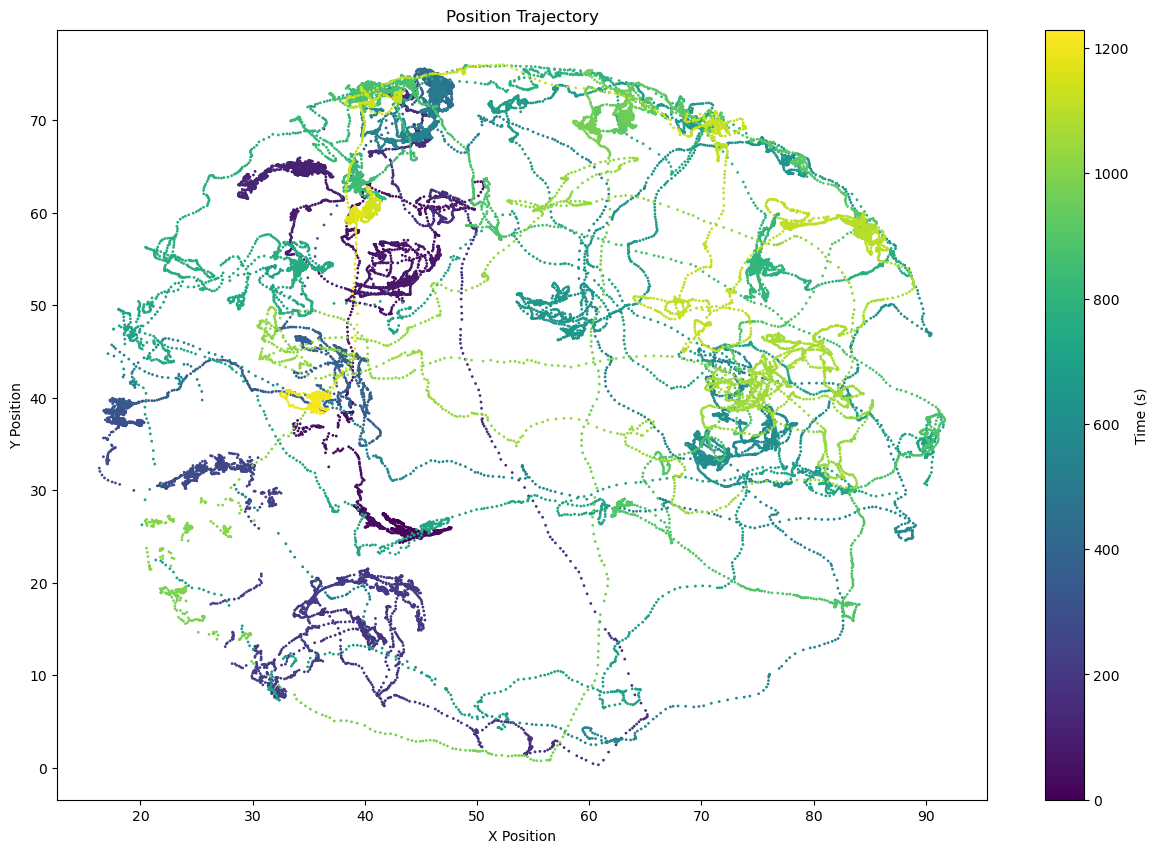

In [10]:
plt.figure(figsize=(15, 10))
x = np.array(tracking_df_epoch1['x'])
y = np.array(tracking_df_epoch1['y'])
timestamps = np.array(tracking_df_epoch1.index)

sc = plt.scatter(x, y, c=timestamps, cmap='viridis', s=1)
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Position Trajectory')
plt.colorbar(sc, label='Time (s)')

Now let's get the sleep data for this session

In [11]:
sgc.IntervalList & {"nwb_file_name": nwb_file_name}

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,valid_times numpy array with start/end times for each interval,pipeline type of interval list
H3022-210805_.nwb,01,=BLOB=,
H3022-210805_.nwb,02,=BLOB=,
H3022-210805_.nwb,03,=BLOB=,
H3022-210805_.nwb,04,=BLOB=,
H3022-210805_.nwb,imported lfp 0 valid times,=BLOB=,imported_lfp
H3022-210805_.nwb,pos 0 valid times,=BLOB=,position
H3022-210805_.nwb,pos 1 valid times,=BLOB=,position
H3022-210805_.nwb,raw data valid times,=BLOB=,
H3022-210805_.nwb,sleep_nrem,=BLOB=,
H3022-210805_.nwb,sleep_rem,=BLOB=,


In [12]:
sgc.Task()

task_name,task_description description of this task,task_type type of task,task_subtype subtype of task
sleep,"The rat was given a 90-minute sleep opportunity in a container placed inside the recording arena, during which recordings continued.",None,None
wake,"The rat was awake and foraging for scattered cereal in a cylindrical open field. The recording environment consisted of a cylindrical arena of 73 cm diameter, with 54 cm tall walls, painted light blue. A prominent visual cue was positioned at the top of the wall on the north side; this was 31.5 cm wide and 26 cm tall and consisted of two black horizontal stripes with a white stripe between them.",None,None
wake_cue_rot,"The rat was awake and foraging for scattered cereal in a cylindrical open field. The recording environment consisted of a cylindrical arena of 73 cm diameter, with 54 cm tall walls, painted light blue. A prominent visual cue was positioned at the top of the wall on the north side; this was 31.5 cm wide and 26 cm tall and consisted of two black horizontal stripes with a white stripe between them.",None,None


In [13]:
sgc.TaskEpoch & {"nwb_file_name": nwb_file_name}

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),task_name,camera_name,interval_list_name descriptive name of this interval list,task_environment the environment the animal was in,camera_names list of keys corresponding to entry in CameraDevice
H3022-210805_.nwb,1,wake,None,01,cylindrical_open_field,=BLOB=
H3022-210805_.nwb,2,sleep,None,02,sleep_container,=BLOB=
H3022-210805_.nwb,3,wake,None,03,cylindrical_open_field,=BLOB=
H3022-210805_.nwb,4,wake_cue_rot,None,04,cylindrical_open_field,=BLOB=


In [14]:
nrem_times = (sgc.IntervalList & {"nwb_file_name": nwb_file_name, "interval_list_name": "sleep_nrem"}).fetch1("valid_times")
rem_times = (sgc.IntervalList & {"nwb_file_name": nwb_file_name, "interval_list_name": "sleep_rem"}).fetch1("valid_times")
wake_times = (sgc.IntervalList & {"nwb_file_name": nwb_file_name, "interval_list_name": "sleep_wake"}).fetch1("valid_times")
epoch_times = []
epoch_task_names = []
for epoch in ["01", "02", "03", "04"]:
    start_time, stop_time = (sgc.IntervalList & {"nwb_file_name": nwb_file_name, "interval_list_name": epoch}).fetch1("valid_times")[0]
    epoch_times.append((start_time, stop_time))
    epoch_int = int(epoch)
    epoch_task_name = (sgc.TaskEpoch & {"nwb_file_name": nwb_file_name, "epoch": epoch_int}).fetch1("task_name")
    epoch_task_names.append(epoch_task_name)

Plot example

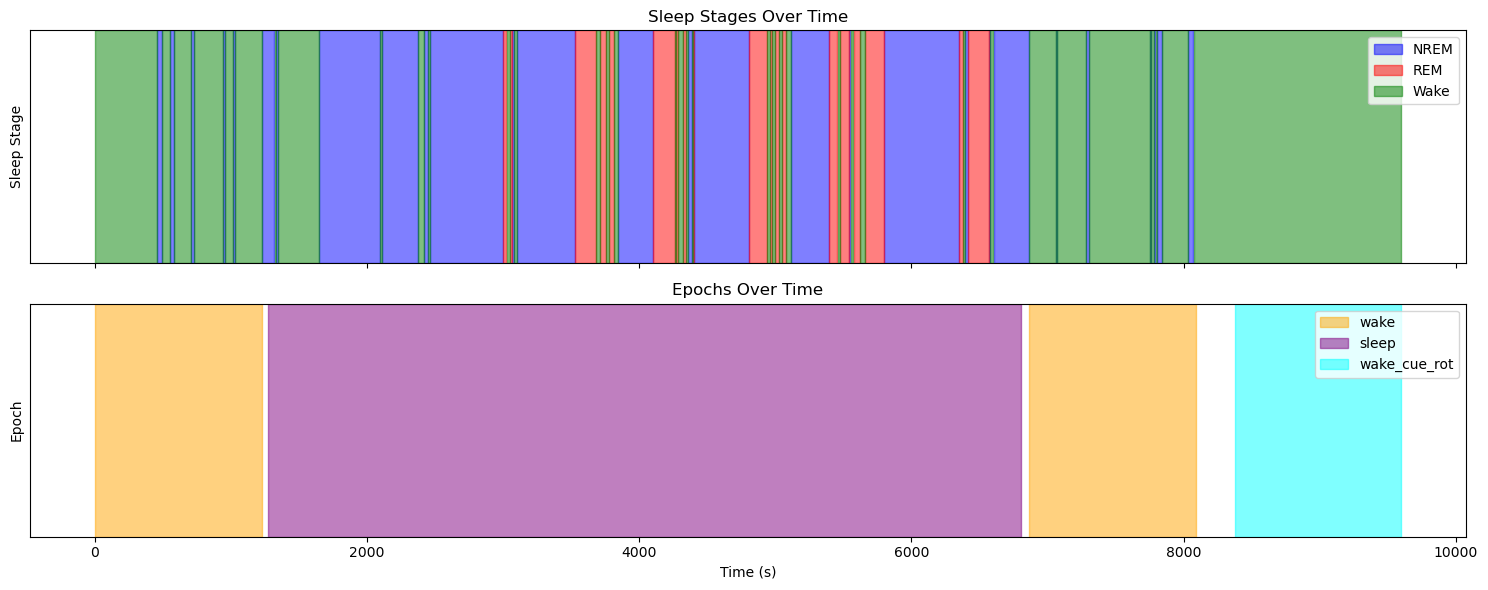

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

# First subplot: Sleep stages
for start, stop in nrem_times:
    ax[0].axvspan(start, stop, alpha=0.5, color='blue', label='NREM')

for start, stop in rem_times:
    ax[0].axvspan(start, stop, alpha=0.5, color='red', label='REM')

for start, stop in wake_times:
    ax[0].axvspan(start, stop, alpha=0.5, color='green', label='Wake')

# Remove duplicate labels in legend for first subplot
handles, labels = ax[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax[0].legend(by_label.values(), by_label.keys())
ax[0].set_ylabel('Sleep Stage')
ax[0].set_yticks([])
ax[0].set_title('Sleep Stages Over Time')

# Second subplot: Epochs
task_color_map = {}
color_palette = ['orange', 'purple', 'cyan', 'yellow']
color_idx = 0

for i, (start, stop) in enumerate(epoch_times):
    task_name = epoch_task_names[i]
    if task_name not in task_color_map:
        task_color_map[task_name] = color_palette[color_idx % len(color_palette)]
        color_idx += 1
    # Only add label for first occurrence of each task
    label = task_name if task_name not in [h.get_label() for h in ax[1].get_children() if hasattr(h, 'get_label')] else None
    ax[1].axvspan(start, stop, alpha=0.5, color=task_color_map[task_name], label=label)

ax[1].legend()
ax[1].set_ylabel('Epoch')
ax[1].set_yticks([])
ax[1].set_title('Epochs Over Time')

ax[1].set_xlabel('Time (s)')
plt.tight_layout()


Now let's get the ephys data for this session. 

In [16]:
plotting_start_time = 600.0
plotting_stop_time = plotting_start_time + 5.0  # 5 second window
print(f"Plotting window: {plotting_start_time} to {plotting_stop_time} seconds")
electrical_series = (sgc.Raw & {"nwb_file_name": nwb_file_name}).fetch_nwb()[0]["raw"]
plotting_start_index = bisect_left(electrical_series.timestamps, plotting_start_time)
plotting_stop_index = bisect_left(electrical_series.timestamps, plotting_stop_time)
plotting_slice = slice(plotting_start_index, plotting_stop_index)
print(f"Plotting indices: {plotting_start_index} to {plotting_stop_index} (exclusive)")

lfp_electrical_series = (sglfp.ImportedLFP & {"nwb_file_name": nwb_file_name}).fetch_nwb()[0]["lfp"]
lfp_plotting_start_index = bisect_left(lfp_electrical_series.timestamps, plotting_start_time)
lfp_plotting_stop_index = bisect_left(lfp_electrical_series.timestamps, plotting_stop_time)
lfp_plotting_slice = slice(lfp_plotting_start_index, lfp_plotting_stop_index)
print(f"LFP Plotting indices: {lfp_plotting_start_index} to {lfp_plotting_stop_index} (exclusive)")

Plotting window: 600.0 to 605.0 seconds
Plotting indices: 18000000 to 18150000 (exclusive)
LFP Plotting indices: 750000 to 756250 (exclusive)


In [17]:
sgc.Electrode()

nwb_file_name name of the NWB file,electrode_group_name electrode group name from NWBFile,electrode_id the unique number for this electrode,probe_id a unique ID for this probe & dynamic config,probe_shank unique shank number within probe.,probe_electrode electrode ID from ShanksElectrode.name,region_id,name unique label for each contact,original_reference_electrode the configured reference electrode for this electrode,x the x coordinate of the electrode position in the brain,y the y coordinate of the electrode position in the brain,z the z coordinate of the electrode position in the brain,filtering description of the signal filtering,impedance electrode impedance,"bad_channel if electrode is ""good"" or ""bad"" as observed during recording",x_warped x coordinate of electrode position warped to common template brain,y_warped y coordinate of electrode position warped to common template brain,z_warped z coordinate of electrode position warped to common template brain,contacts label of electrode contacts used for a bipolar signal - current workaround
H3022-210805_.nwb,probe1_shank1,0,Cambridge Neurotech H6b probe,1,0,1,0,-1,nan,nan,nan,unfiltered,nan,True,0.0,0.0,0.0,
H3022-210805_.nwb,probe1_shank1,1,Cambridge Neurotech H6b probe,1,1,1,1,-1,nan,nan,nan,unfiltered,nan,True,0.0,0.0,0.0,
H3022-210805_.nwb,probe1_shank1,2,Cambridge Neurotech H6b probe,1,2,1,2,-1,nan,nan,nan,unfiltered,nan,True,0.0,0.0,0.0,
H3022-210805_.nwb,probe1_shank1,3,Cambridge Neurotech H6b probe,1,3,1,3,-1,nan,nan,nan,unfiltered,nan,True,0.0,0.0,0.0,
H3022-210805_.nwb,probe1_shank1,4,Cambridge Neurotech H6b probe,1,4,1,4,-1,nan,nan,nan,unfiltered,nan,True,0.0,0.0,0.0,
H3022-210805_.nwb,probe1_shank1,5,Cambridge Neurotech H6b probe,1,5,1,5,-1,nan,nan,nan,unfiltered,nan,True,0.0,0.0,0.0,
H3022-210805_.nwb,probe1_shank1,6,Cambridge Neurotech H6b probe,1,6,1,6,-1,nan,nan,nan,unfiltered,nan,True,0.0,0.0,0.0,
H3022-210805_.nwb,probe1_shank1,7,Cambridge Neurotech H6b probe,1,7,1,7,-1,nan,nan,nan,unfiltered,nan,True,0.0,0.0,0.0,
H3022-210805_.nwb,probe1_shank1,8,Cambridge Neurotech H6b probe,1,8,1,8,-1,nan,nan,nan,unfiltered,nan,True,0.0,0.0,0.0,
H3022-210805_.nwb,probe1_shank1,9,Cambridge Neurotech H6b probe,1,9,1,9,-1,nan,nan,nan,unfiltered,nan,True,0.0,0.0,0.0,


Retrieve Ephys Data for first electrode

In [18]:
# Ephys
electrical_series_data = electrical_series.data[plotting_slice, 0]
raw_to_uV = electrical_series.conversion * 1e6
electrical_series_in_uV = electrical_series_data * raw_to_uV
electrical_series_timestamps = np.asarray(electrical_series.timestamps[plotting_slice])
lfp_data = np.asarray(lfp_electrical_series.data[lfp_plotting_slice, 0])
lfp_conversion = lfp_electrical_series.conversion * 1e6
lfp_in_uV = lfp_data * lfp_conversion
lfp_timestamps = np.asarray(lfp_electrical_series.timestamps[lfp_plotting_slice])

Plot example

Text(0.5, 0, 'Time (s)')

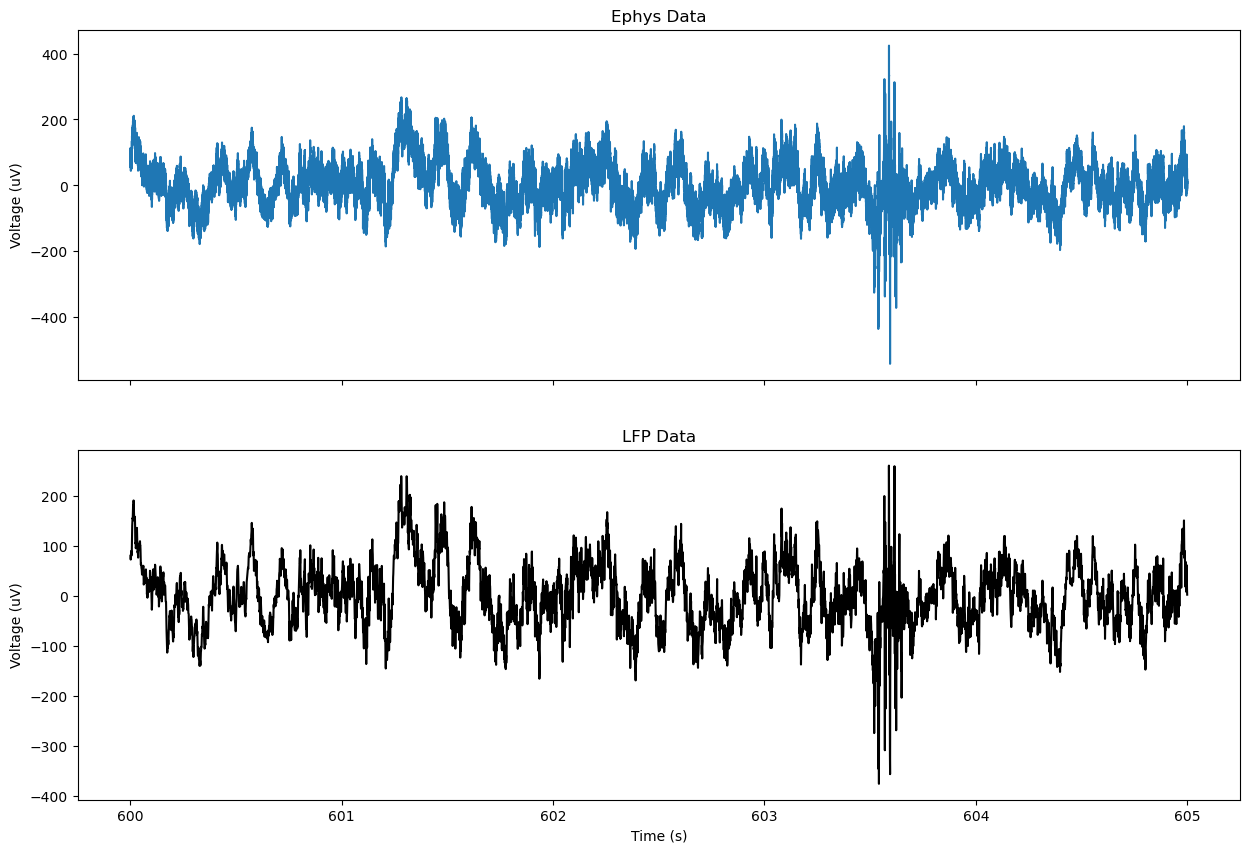

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
ax[0].plot(electrical_series_timestamps, electrical_series_in_uV)
ax[0].set_ylabel("Voltage (uV)")
ax[0].set_title("Ephys Data")

ax[1].plot(lfp_timestamps, lfp_in_uV, color='black')
ax[1].set_ylabel("Voltage (uV)")
ax[1].set_title("LFP Data")
ax[1].set_xlabel("Time (s)")